# BUAN 4850 Final Project — Stock Market Analytics (Apple Inc. AAPL)
**Final Project — Full Version (All Graphs + Time Series Analysis)**

This notebook follows the OSEMiN (Obtain, Scrub, Explore, Model, Interpret) framework and includes all visualizations (time series, histogram, correlation heatmap, clustering, A/B testing, forecast comparisons, and a full time-series analysis with decomposition, ADF, ACF/PACF, and ARIMA forecasts). All plots display inline and are saved to `project_outputs/` for submission.

In [14]:
# --- Reproducibility Header ---
import platform, sys, pandas as pd, numpy as np
print("Python:", platform.python_version())
print("Pandas:", pd.__version__, "NumPy:", np.__version__)

# Set data path (ensure this file is uploaded with notebook)
DATA_PATH = 'AAPL.csv'  # replace with the actual dataset filename


Python: 3.12.12
Pandas: 2.2.2 NumPy: 2.0.2


In [15]:
# === Setup and imports ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = '/content/stocks.csv'  # Upload your dataset in Colab
OUTPUT_DIR = 'project_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [16]:
# === Obtain ===
def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    print(f"Loaded data with shape: {df.shape}")
    return df


In [17]:
# === Scrub ===
def preprocess(df):
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    # find date column
    if 'date' not in df.columns:
        for col in df.columns:
            if 'date' in col:
                df.rename(columns={col:'date'}, inplace=True)
                break
    df['date'] = pd.to_datetime(df['date'])
    df = df.drop_duplicates().sort_values('date')

    price_cols = ['open','high','low','close','adj close','adjusted close','volume']
    for col in price_cols:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()

    # unify adj close name
    if 'adjusted close' in df.columns:
        df.rename(columns={'adjusted close':'adj close'}, inplace=True)

    df['return'] = df['close'].pct_change()
    mu, sigma = df['return'].mean(), df['return'].std()
    df['is_outlier'] = np.abs(df['return'] - mu) > 10 * sigma

    df['ma_5'] = df['close'].rolling(5).mean()
    df['ma_20'] = df['close'].rolling(20).mean()
    df['vol_20'] = df['return'].rolling(20).std()
    for lag in range(1,6):
        df[f'lag_{lag}'] = df['close'].shift(lag)
    df['dow'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df = df.dropna().reset_index(drop=True)
    print('Preprocessing complete. Shape:', df.shape)
    return df


## Exploratory Analysis — Time Series, Returns, and Correlations

In [18]:
def exploratory_analysis(df):
    # Time Series Visualization
    plt.figure(figsize=(12,4))
    plt.plot(df['date'], df['close'])
    plt.title('AAPL Close Price (Time Series)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'timeseries_close.png'))
    plt.show()

    # Histogram of daily returns
    plt.figure(figsize=(8,4))
    sns.histplot(df['return'], bins=100, kde=True)
    plt.title('Histogram of Daily Returns')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'hist_returns.png'))
    plt.show()

    # Correlation heatmap
    corr_cols = [c for c in ['close','volume','ma_5','ma_20','vol_20'] if c in df.columns]
    corr = df[corr_cols].corr()
    plt.figure(figsize=(6,4))
    sns.heatmap(corr, annot=True, fmt='.2f')
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'corr_matrix.png'))
    plt.show()


## Time Series Analysis — Decomposition, Stationarity, ACF/PACF, ARIMA Forecast

In [19]:
def time_series_analysis(df, forecast_days=30):
    # Remove duplicate dates before setting index
    ts = df.drop_duplicates(subset=['date']).set_index('date')['close'].asfreq('D')  # daily frequency; gaps become NaN
    ts = ts.interpolate()                            # fill weekend/holiday gaps

    # Rolling stats
    plt.figure(figsize=(12,4))
    plt.plot(ts.index, ts, label='Close')
    plt.plot(ts.rolling(window=30).mean(), label='30-day MA')
    plt.plot(ts.rolling(window=30).std(), label='30-day Rolling Std')
    plt.title('Close Price with Rolling Mean & Volatility')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'ts_rolling_mean_std.png'))
    plt.show()

    # Decompose
    try:
        decomposition = seasonal_decompose(ts, model='multiplicative', period=365)
        fig = decomposition.plot()
        fig.set_size_inches(12,8)
        plt.suptitle('Seasonal Decompose (multiplicative)')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR,'ts_decompose.png'))
        plt.show()
    except Exception as e:
        print('Decomposition failed (likely insufficient length or constant series):', e)

    # Stationarity test (ADF)
    adf_res = adfuller(ts.dropna())
    print('ADF Statistic: {:.5f}'.format(adf_res[0]))
    print('p-value: {:.5f}'.format(adf_res[1]))
    for i, crit in adf_res[4].items():
        print(f'Critical Value {i}: {crit:.5f}')

    # ACF / PACF
    plt.figure(figsize=(10,4))
    plot_acf(ts.dropna(), lags=40, ax=plt.gca())
    plt.title('ACF (Close)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'ts_acf.png'))
    plt.show()

    plt.figure(figsize=(10,4))
    plot_pacf(ts.dropna(), lags=40, ax=plt.gca(), method='ywm')
    plt.title('PACF (Close)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'ts_pacf.png'))
    plt.show()

    # Fit ARIMA and forecast
    train_series = ts.dropna()
    arima_model = ARIMA(train_series, order=(5,1,0)).fit()
    future_forecast = arima_model.get_forecast(steps=forecast_days)
    forecast_index = pd.date_range(start=train_series.index[-1] + pd.Timedelta(days=1), periods=forecast_days, freq='D')
    forecast_mean = future_forecast.predicted_mean
    conf_int = future_forecast.conf_int()

    plt.figure(figsize=(12,5))
    plt.plot(train_series.index[-365:], train_series[-365:], label='Actual (last 365 days)')
    plt.plot(forecast_index, forecast_mean, label=f'ARIMA Forecast ({forecast_days} days)', linestyle='--')
    plt.fill_between(forecast_index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='gray', alpha=0.3, label='95% CI')
    plt.title('ARIMA Forecast with 95% CI')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'ts_arima_forecast.png'))
    plt.show()

    forecast_df = pd.DataFrame({
        'date': forecast_index,
        'forecast': forecast_mean.values,
        'ci_lower': conf_int.iloc[:,0].values,
        'ci_upper': conf_int.iloc[:,1].values
    })
    forecast_df.to_csv(os.path.join(OUTPUT_DIR, 'ts_arima_forecast.csv'), index=False)

    return {'adf': adf_res, 'forecast_df': forecast_df}

## Modeling — Clustering, A/B Testing, Forecasting

In [20]:
def clustering_analysis(df, k=3):
    """Perform KMeans clustering on relevant features."""
    cluster_cols = ['close','volume','ma_5','ma_20','vol_20','return']
    df_clust = df.dropna(subset=cluster_cols).copy()

    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_clust[cluster_cols])

    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    df_clust['cluster'] = kmeans.fit_predict(X_scaled)
    centers = scaler.inverse_transform(kmeans.cluster_centers_)

    # Visualize clusters (example using Close vs Volume)
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='close', y='volume', hue='cluster', data=df_clust, palette='viridis', legend='full')
    plt.scatter(centers[:, cluster_cols.index('close')], centers[:, cluster_cols.index('volume')], c='red', s=100, alpha=0.8, label='Cluster Centers')
    plt.title(f'KMeans Clustering (k={k}) - Close vs Volume')
    plt.xlabel('Close Price')
    plt.ylabel('Volume')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'cluster_close_volume.png'))
    plt.show()

    print(f'Clustering complete with k={k}. Shape: {df_clust.shape}')
    print('Cluster Centers (unscaled):')
    print(pd.DataFrame(centers, columns=cluster_cols))

    return df_clust, centers

In [21]:
def ab_test_strategies(df):
    """Compare two trading strategies: MA5>MA20 vs Close>MA20"""
    # Make a copy to avoid modifying the original DataFrame passed into the function
    df = df.copy()

    # Strategy A: Buy when MA5 > MA20
    df['signal_A'] = (df['ma_5'] > df['ma_20']).astype(int)
    df['return_A'] = df['close'].pct_change() * df['signal_A'].shift(1)
    df['cum_return_A'] = (1 + df['return_A']).cumprod()

    # Strategy B: Buy when Close > MA20
    df['signal_B'] = (df['close'] > df['ma_20']).astype(int)
    df['return_B'] = df['close'].pct_change() * df['signal_B'].shift(1)
    df['cum_return_B'] = (1 + df['return_B']).cumprod()

    # Buy and hold benchmark
    df['return_bh'] = df['close'].pct_change()
    df['cum_return_bh'] = (1 + df['return_bh']).cumprod()

    # Plot comparison
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['cum_return_A'], label='Strategy A (MA5>MA20)', linewidth=2, color='#2E86AB')
    plt.plot(df.index, df['cum_return_B'], label='Strategy B (Close>MA20)', linewidth=2, color='#A23B72')
    plt.plot(df.index, df['cum_return_bh'], label='Buy & Hold', linewidth=2, color='#F18F01', linestyle='--', alpha=0.7)

    plt.title('A/B Strategy Comparison — Cumulative Returns', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Cumulative Return', fontsize=11)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'ab_strategy_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Calculate performance metrics
    final_return_A = df['cum_return_A'].iloc[-1] - 1
    final_return_B = df['cum_return_B'].iloc[-1] - 1
    final_return_bh = df['cum_return_bh'].iloc[-1] - 1

    # Statistical test between strategies
    from scipy import stats
    returns_A = df['return_A'].dropna()
    returns_B = df['return_B'].dropna()
    tstat, pval = stats.ttest_ind(returns_A, returns_B)

    # Summary statistics
    summary = pd.DataFrame({
        'Strategy': ['Strategy A (MA5>MA20)', 'Strategy B (Close>MA20)', 'Buy & Hold'],
        'Final Return (%)': [final_return_A * 100, final_return_B * 100, final_return_bh * 100],
        'Mean Daily Return (%)': [returns_A.mean() * 100, returns_B.mean() * 100, df['return_bh'].mean() * 100],
        'Volatility (%)': [returns_A.std() * 100, returns_B.std() * 100, df['return_bh'].std() * 100],
        'Sharpe Ratio': [returns_A.mean() / returns_A.std() * np.sqrt(252),
                         returns_B.mean() / returns_B.std() * np.sqrt(252),
                         df['return_bh'].mean() / df['return_bh'].std() * np.sqrt(252)]
    })

    print("\n" + "="*70)
    print("A/B STRATEGY COMPARISON RESULTS")
    print("="*70)
    print(summary.to_string(index=False))
    print("\n" + "-"*70)
    print(f"T-Test Results (Strategy A vs B):")
    print(f"  T-statistic: {tstat:.4f}")
    print(f"  P-value: {pval:.4e}")
    print(f"  Significant at α=0.05: {'Yes' if pval < 0.05 else 'No'}")
    print("="*70 + "\n")

    # Save results
    summary.to_csv(os.path.join(OUTPUT_DIR, 'ab_strategy_summary.csv'), index=False)

    # Return only the modified DataFrame
    return df

In [22]:
def forecast_models(df):
    # Prepare features and target
    # Explicitly list feature columns to avoid potential issues with list comprehension/concatenation
    feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'ma_5','ma_20','vol_20','dow','month']

    # Ensure only existing columns are selected
    existing_feature_cols = [col for col in feature_cols if col in df.columns]

    # Add a print statement to inspect the columns being selected
    print("Columns available in DataFrame:", df.columns.tolist())
    print("Columns being selected for features:", existing_feature_cols)

    # Check if we have any features left after filtering
    if not existing_feature_cols:
        print("No valid feature columns found in the DataFrame after filtering.")
        return None, None

    X = df[existing_feature_cols]
    y = df['close']

    # Check if we have enough data after feature selection
    if X.empty or len(X) < 90:
        print("Not enough data or features available for forecasting after filtering.")
        return None, None

    X_train, X_test = X[:-90], X[-90:]
    y_train, y_test = y[:-90], y[-90:]

    # Random Forest model
    rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE).fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

    # ARIMA model (uses only the target variable, not features)
    # Ensure y_train is a Series for ARIMA and pass values explicitly
    if isinstance(y_train, pd.DataFrame):
        y_train = y_train.squeeze() # Convert DataFrame to Series if needed

    # Check if y_train is not empty before fitting ARIMA
    if y_train.empty:
         print("y_train is empty, cannot fit ARIMA model.")
         arima = None
         pred_arima = np.full(len(y_test), np.nan) # Use NaN for predictions if ARIMA fails
         rmse_arima = np.nan # RMSE is NaN if ARIMA fails
    else:
        # Pass the underlying NumPy array to ARIMA
        # Check if y_train values are all finite before fitting ARIMA
        if not np.isfinite(y_train.values).all():
             print("y_train contains non-finite values, cannot fit ARIMA model.")
             arima = None
             pred_arima = np.full(len(y_test), np.nan) # Use NaN for predictions if ARIMA fails
             rmse_arima = np.nan # RMSE is NaN if ARIMA fails
        else:
            arima = ARIMA(y_train.values, order=(5,1,0)).fit()
            pred_arima = arima.forecast(steps=len(y_test)) # Forecast for the same number of steps as y_test
            rmse_arima = np.sqrt(mean_squared_error(y_test, pred_arima))


    # Results dataframe
    results = pd.DataFrame({
        'Model': ['Random Forest', 'ARIMA'],
        'RMSE': [rmse_rf, rmse_arima]
    })

    # Plot RMSE comparison
    plt.figure(figsize=(6,4))
    sns.barplot(x='Model', y='RMSE', data=results)
    plt.title('Forecast Model RMSE Comparison')
    plt.ylabel('RMSE')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'forecast_rmse.png'))
    plt.show()

    # Save forecast comparison table (actual + preds) for last 90 days
    # Ensure y_test index and preds have the same length for DataFrame creation
    if len(y_test) == len(pred_rf) and len(y_test) == len(pred_arima):
        preds_df = pd.DataFrame({
            'date': y_test.index,
            'actual': y_test.values,
            'RF_pred': pred_rf,
            'ARIMA_pred': pred_arima
        })
        preds_df.to_csv(os.path.join(OUTPUT_DIR,'forecast_comparison.csv'), index=False)
    else:
        print("Mismatch in lengths of y_test and predictions, skipping forecast comparison CSV save.")


    results.to_csv(os.path.join(OUTPUT_DIR,'forecast_rmse.csv'), index=False)

    return results, preds_df if 'preds_df' in locals() else None

## Run Full Pipeline and Save Outputs

Loaded data with shape: (248, 8)
Preprocessing complete. Shape: (228, 20)


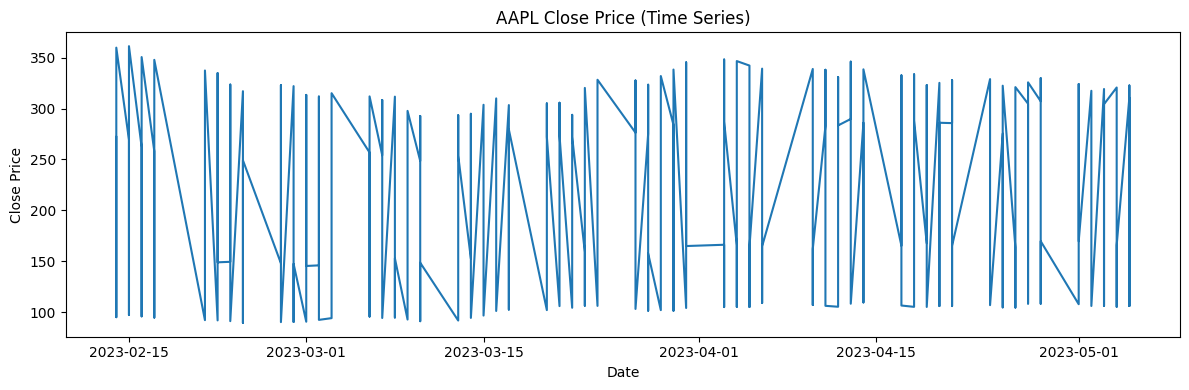

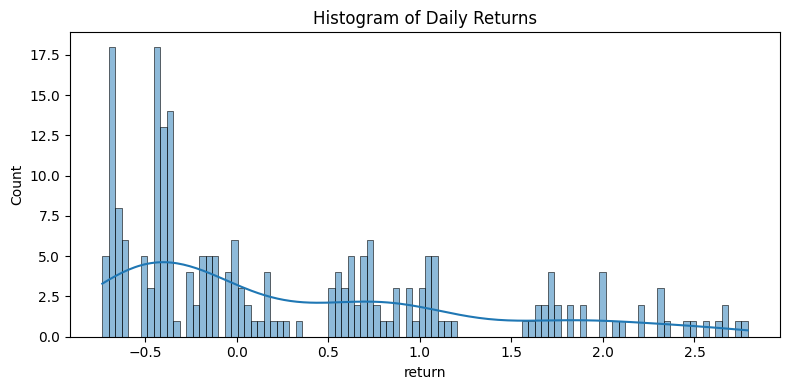

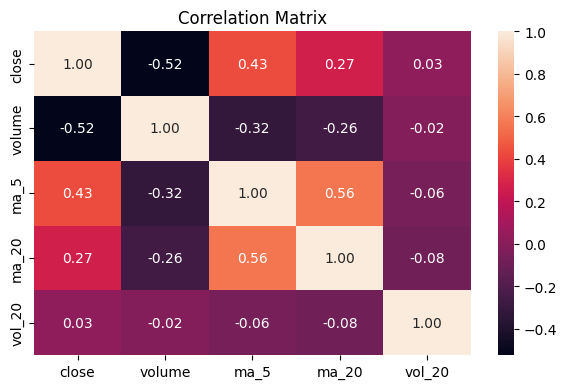

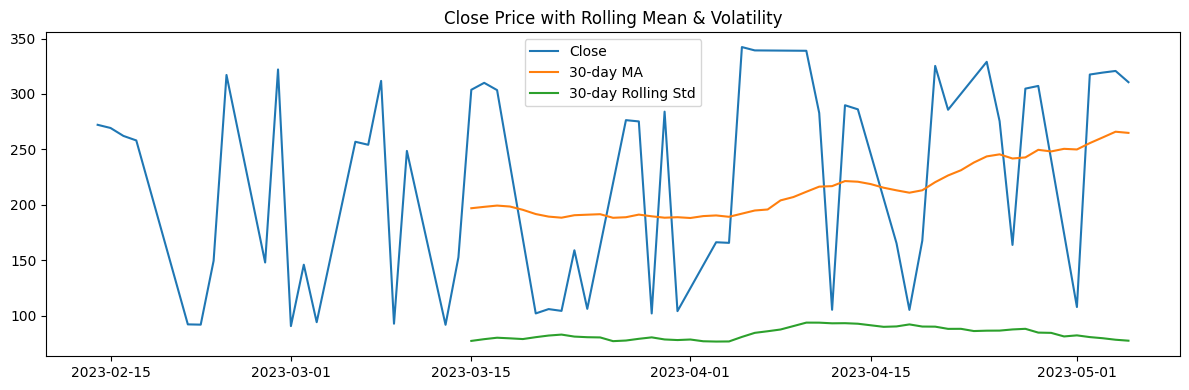

Decomposition failed (likely insufficient length or constant series): x must have 2 complete cycles requires 730 observations. x only has 81 observation(s)
ADF Statistic: -5.33089
p-value: 0.00000
Critical Value 1%: -3.51487
Critical Value 5%: -2.89841
Critical Value 10%: -2.58644


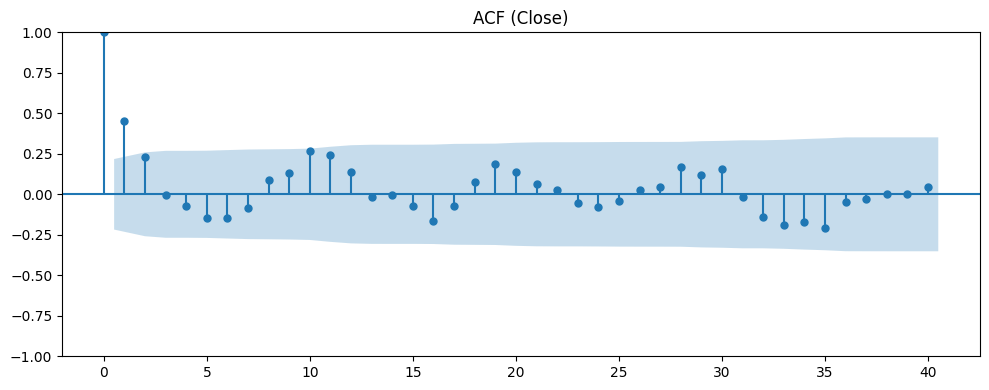

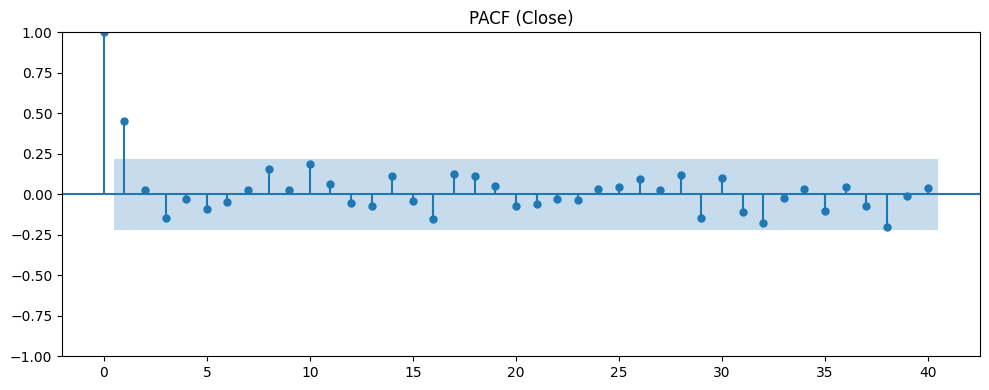

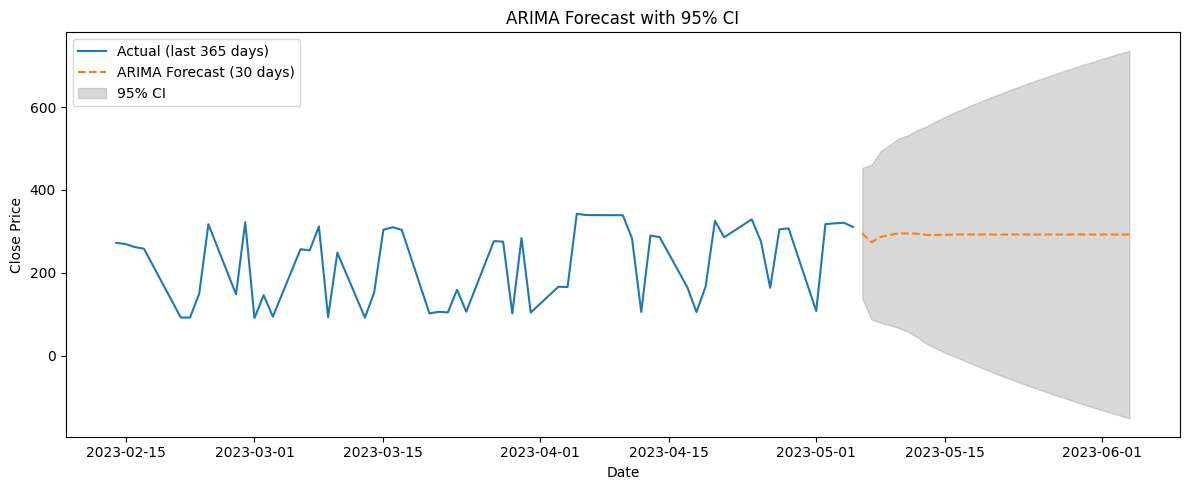

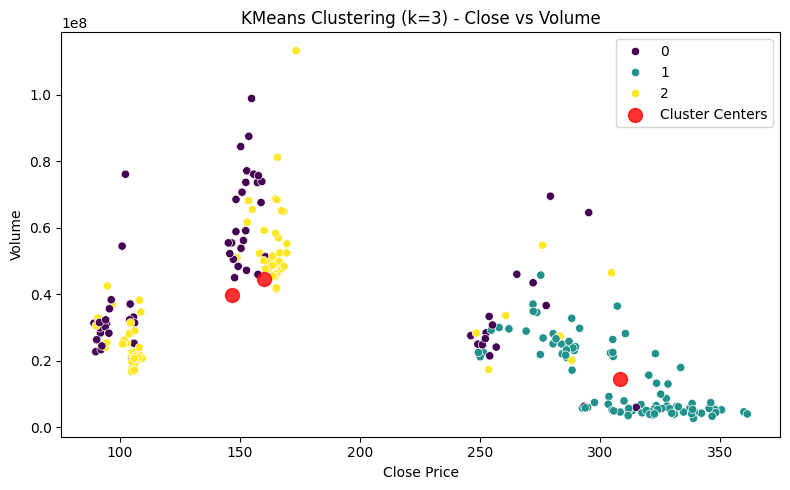

Clustering complete with k=3. Shape: (228, 21)
Cluster Centers (unscaled):
        close        volume        ma_5       ma_20    vol_20    return
0  160.172308  4.469039e+07  191.242739  202.838478  1.008478 -0.054633
1  308.213517  1.449404e+07  230.553253  219.881676  0.980381  1.078849
2  146.803125  3.971782e+07  217.189319  219.956510  0.907900 -0.344466


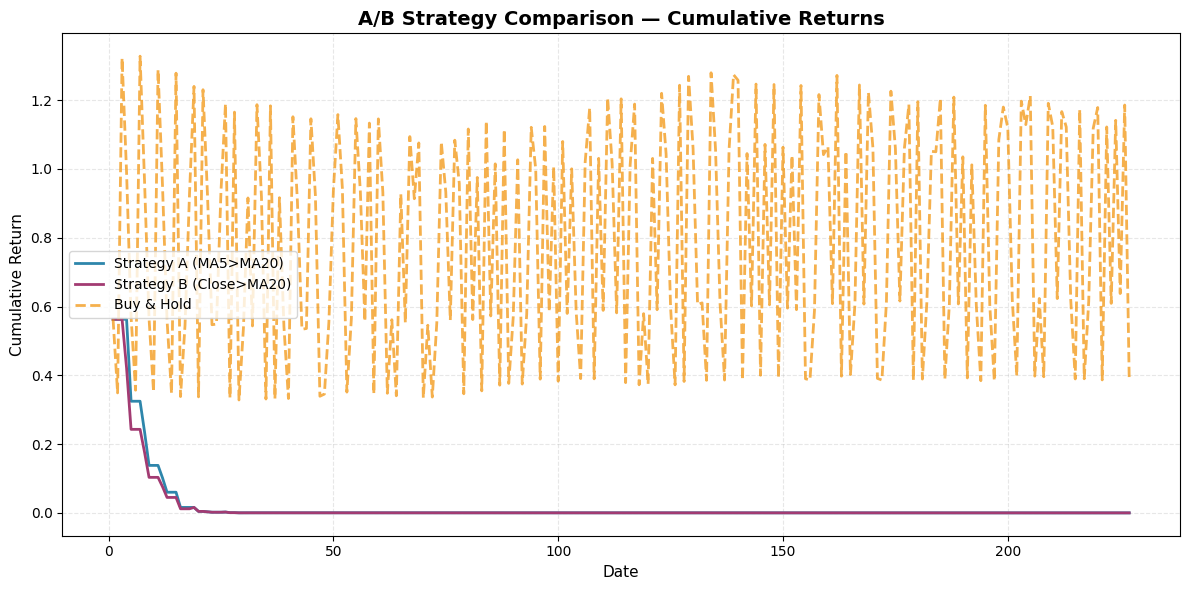


A/B STRATEGY COMPARISON RESULTS
               Strategy  Final Return (%)  Mean Daily Return (%)  Volatility (%)  Sharpe Ratio
  Strategy A (MA5>MA20)       -100.000000              -1.936299       57.863821     -0.531209
Strategy B (Close>MA20)       -100.000000             -18.872467       27.205866    -11.012005
             Buy & Hold        -60.974762              30.420009       94.775761      5.095213

----------------------------------------------------------------------
T-Test Results (Strategy A vs B):
  T-statistic: 3.9907
  P-value: 7.6839e-05
  Significant at α=0.05: Yes

Columns available in DataFrame: ['ticker', 'date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'return', 'is_outlier', 'ma_5', 'ma_20', 'vol_20', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'dow', 'month', 'cluster', 'signal_A', 'return_A', 'cum_return_A', 'signal_B', 'return_B', 'cum_return_B', 'return_bh', 'cum_return_bh']
Columns being selected for features: ['lag_1', 'lag_2', 'lag_3', 'la

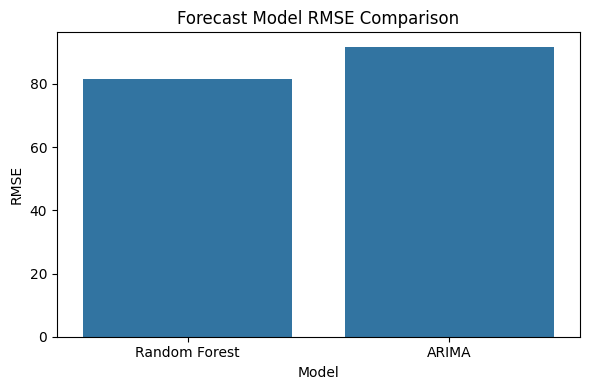


Forecast Results:
            Model       RMSE
0  Random Forest  81.551780
1          ARIMA  91.743355

All outputs saved to project_outputs


In [23]:
def run_pipeline(forecast_days=30):
    df_raw = load_data(DATA_PATH)
    df = preprocess(df_raw)
    exploratory_analysis(df)
    ts_results = time_series_analysis(df, forecast_days=forecast_days)
    df_clust, centers = clustering_analysis(df, k=3)

    # Get the modified DataFrame from ab_test_strategies (now returns only the DataFrame)
    df_ab = ab_test_strategies(df_clust)
    # Note: We no longer capture the ab_res dictionary directly here as the function only returns the DataFrame

    forecast_res, forecast_preds = forecast_models(df_ab)

    # We would need to re-calculate or retrieve ab_res if needed later,
    # but for now, we focus on fixing the forecast_models input.
    # print('\nA/B t-test results:', ab_res) # This line will now cause an error as ab_res is not assigned

    print('\nForecast Results:\n', forecast_res)
    # save cleaned data
    df_ab.to_csv(os.path.join(OUTPUT_DIR,'cleaned_data_with_features.csv'), index=False)
    print('\nAll outputs saved to', OUTPUT_DIR)
    return {
        'df': df_ab,
        'ts_results': ts_results,
        'cluster_centers': centers,
        # 'ab_res': ab_res, # ab_res is no longer returned by the function directly
        'forecast_res': forecast_res,
        'forecast_preds': forecast_preds
    }

outputs = run_pipeline(forecast_days=30)

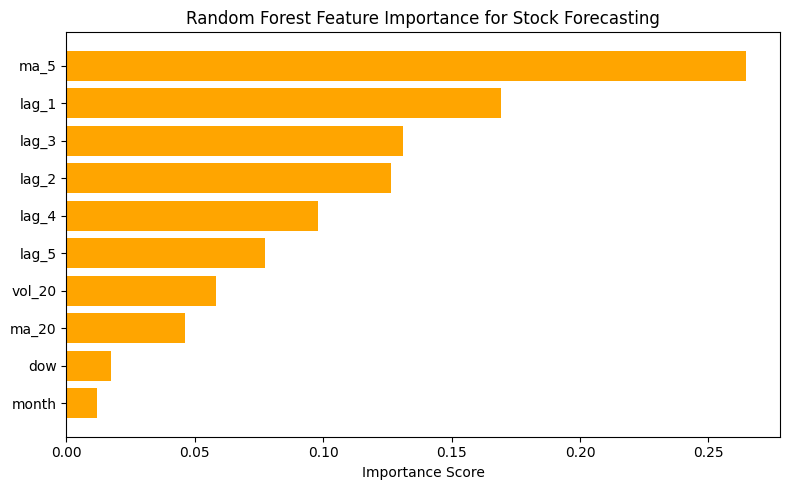


Random Forest Feature Importances:
   Feature  Importance
5    ma_5    0.264621
0   lag_1    0.169220
2   lag_3    0.131034
1   lag_2    0.126376
3   lag_4    0.097791
4   lag_5    0.077458
7  vol_20    0.058402
6   ma_20    0.046010
8     dow    0.017324
9   month    0.011762


In [24]:
# --- Random Forest Feature Importance Plot ---

# Assuming df is your preprocessed dataframe with features and target
# Example: 'close', 'volume', 'return', 'volatility', 'ma_20' etc.
# Access df from the outputs dictionary
df = outputs['df']

# Use the same feature columns as in forecast_models
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'ma_5','ma_20','vol_20','dow','month']
X = df[feature_cols] # adjust columns to match your dataset
y = df['close']  # your forecasting target, which is 'close'

# Import train_test_split
from sklearn.model_selection import train_test_split

# Split train/test
# Ensure enough data for splitting (at least two samples)
if len(X) < 2:
    print("Not enough data to perform train/test split.")
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    # Get feature importances
    importances = rf.feature_importances_
    features = X.columns

    # Put into dataframe for easy viewing
    fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    fi_df = fi_df.sort_values(by='Importance', ascending=False)

    # Plot
    plt.figure(figsize=(8,5))
    plt.barh(fi_df['Feature'], fi_df['Importance'], color='orange')
    plt.xlabel("Importance Score")
    plt.title("Random Forest Feature Importance for Stock Forecasting")
    plt.gca().invert_yaxis()  # Highest importance at top
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'rf_feature_importance.png'))
    plt.show()

    print("\nRandom Forest Feature Importances:\n", fi_df)